In [1]:
# import libraries:

import pandas as pd
import matplotlib.pyplot as plt

df= pd.read_csv("C:/Users/user/Downloads/sales_visualization_practice_1000_rows.csv")
print(df.head())

   order_id        date     product     category       city customer_type  \
0     10001  2025-05-25       Mouse  Accessories   Peshawar     Returning   
1     10002  2025-07-20  Headphones  Accessories     Lahore           New   
2     10003  2025-07-31     Monitor  Electronics     Quetta           New   
3     10004  2025-08-08       Mouse  Accessories  Islamabad           New   
4     10005  2025-08-28      Tablet  Electronics     Lahore     Returning   

  payment_method  quantity  unit_price  discount    sales  
0         Online         5        3500      0.10  15750.0  
1         Online         3       12000      0.04  34560.0  
2         Online         1       45000      0.14  38700.0  
3         Online         4        3500      0.07  13020.0  
4           Card         2       55000      0.23  84700.0  


In [2]:
# dataset understanding:

print("SHAPE OF DATASET:")
print(df.shape)
print("\n COLUMNS OF DATASET:")
print(df.columns)
print("\n DATA TYPES:")
print(df.dtypes)
print("\n DATSET INFORMATION:")
print(df.info())

SHAPE OF DATASET:
(1000, 11)

 COLUMNS OF DATASET:
Index(['order_id', 'date', 'product', 'category', 'city', 'customer_type',
       'payment_method', 'quantity', 'unit_price', 'discount', 'sales'],
      dtype='object')

 DATA TYPES:
order_id            int64
date               object
product            object
category           object
city               object
customer_type      object
payment_method     object
quantity            int64
unit_price          int64
discount          float64
sales             float64
dtype: object

 DATSET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        1000 non-null   int64  
 1   date            1000 non-null   object 
 2   product         1000 non-null   object 
 3   category        1000 non-null   object 
 4   city            990 non-null    object 
 5   customer_type   1

In [3]:
# statistical summry:

print(df.describe())

           order_id     quantity     unit_price    discount          sales
count   1000.000000  1000.000000    1000.000000  990.000000    1000.000000
mean   10500.500000     2.986000   47106.500000    0.121475  127326.740000
std      288.819436     1.414852   47827.553592    0.072191  155387.149335
min    10001.000000     1.000000    3500.000000    0.000000    2625.000000
25%    10250.750000     2.000000   12000.000000    0.060000   19635.000000
50%    10500.500000     3.000000   18000.000000    0.120000   54525.000000
75%    10750.250000     4.000000   62500.000000    0.180000  184575.000000
max    11000.000000     5.000000  150000.000000    0.250000  735000.000000


In [4]:
# finding null values:

print(df.isnull().sum())

order_id           0
date               0
product            0
category           0
city              10
customer_type      0
payment_method    10
quantity           0
unit_price         0
discount          10
sales              0
dtype: int64


In [3]:
# fiiling null with median:

df["city"] = df["city"].fillna(df["city"].mode()[0])
df["discount"] = df["discount"].fillna(df["discount"].median())
df["payment_method"] = df["payment_method"].fillna(df["payment_method"].mode()[0])
print(df.isnull().sum())

order_id          0
date              0
product           0
category          0
city              0
customer_type     0
payment_method    0
quantity          0
unit_price        0
discount          0
sales             0
dtype: int64


In [5]:
# converting date column into date format:

df["date"] = pd.to_datetime(df["date"])
print(df["date"].dtypes)



datetime64[ns]


product
Laptop        55678500.0
Mobile        27573150.0
Tablet        15287800.0
Monitor       14937750.0
Smartwatch     6260760.0
Headphones     4603560.0
Keyboard       1893920.0
Mouse          1091300.0
Name: sales, dtype: float64
127326740.0


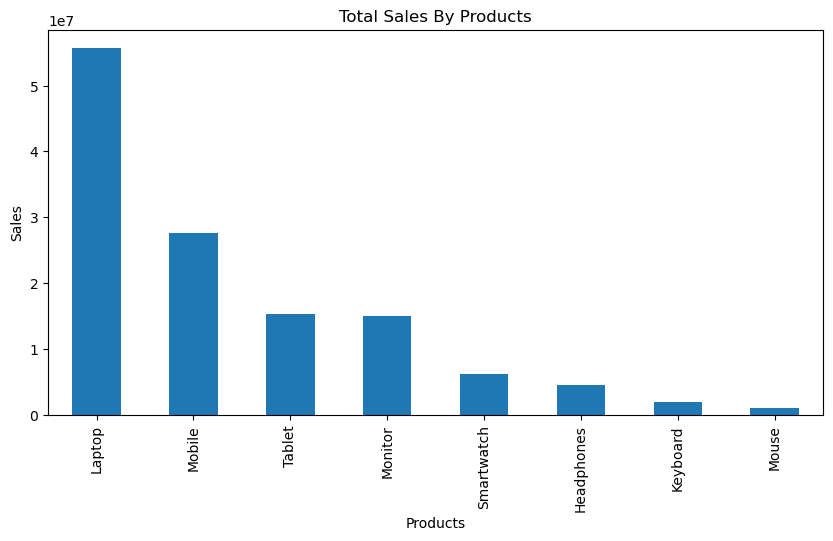

In [6]:
# CREATING BAR CHART:
# "TOTAL SALES BY PRODUCTS"

product_sales = (df.groupby("product")["sales"].sum().sort_values(ascending = False))
print(product_sales)
print(df["sales"].sum())

plt.figure(figsize = (10, 5))
product_sales.plot(kind= "bar")
plt.title("Total Sales By Products")
plt.xlabel("Products")
plt.ylabel("Sales")

plt.show()

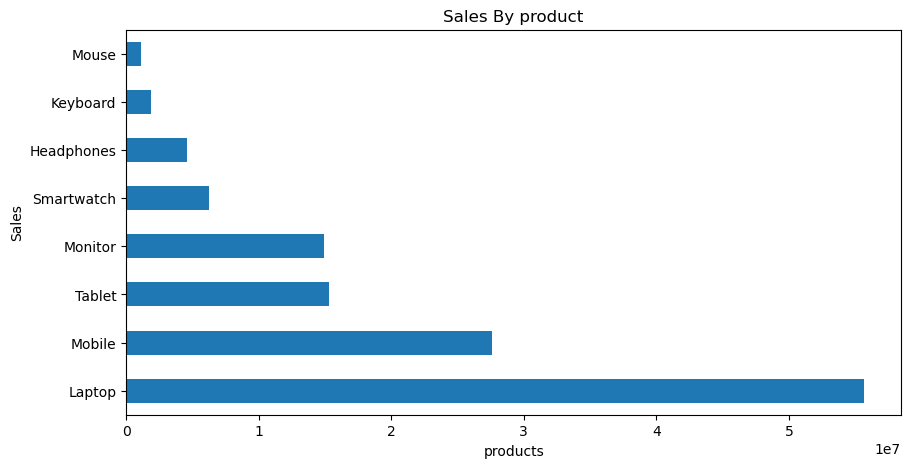

In [7]:
# horizental bar:

plt.figure(figsize= (10, 5))
product_sales.plot(kind= "barh")
plt.title("Sales By product")
plt.xlabel("products")
plt.ylabel("Sales")
plt.show()

In [8]:
# SALES BY CITY:

city_sales = df.groupby("city")["sales"].sum().sort_values(ascending = False)
print(city_sales)

city
Multan        17552190.0
Lahore        17165160.0
Rawalpindi    16522290.0
Peshawar      16502660.0
Quetta        15611330.0
Islamabad     15243615.0
Karachi       14983365.0
Faisalabad    13746130.0
Name: sales, dtype: float64


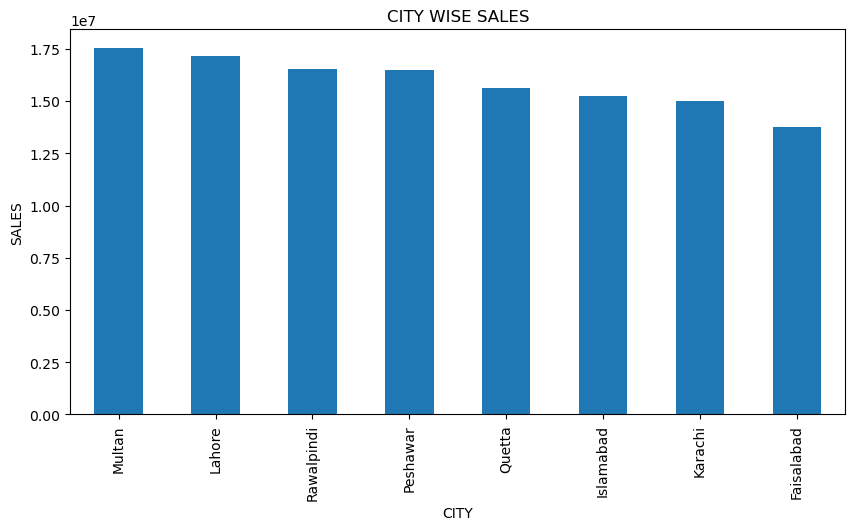

In [9]:
# bar graph of city wise sales:

plt.figure(figsize= (10, 5))
city_sales.plot(kind= "bar")
plt.title("CITY WISE SALES")
plt.xlabel("CITY")
plt.ylabel("SALES")
plt.show()

In [10]:
# LINE CHARTS:
# DAILY SALES TREND

daily_sales= df.groupby("date")["sales"].sum().sort_values(ascending= False)
print(daily_sales)

date
2025-05-13    1743600.0
2025-03-31    1381500.0
2025-04-08    1354460.0
2025-08-24    1319850.0
2025-11-24    1291790.0
                ...    
2025-09-15       5530.0
2025-11-04       5460.0
2025-01-27       3500.0
2025-11-03       2870.0
2025-05-24       2835.0
Name: sales, Length: 340, dtype: float64


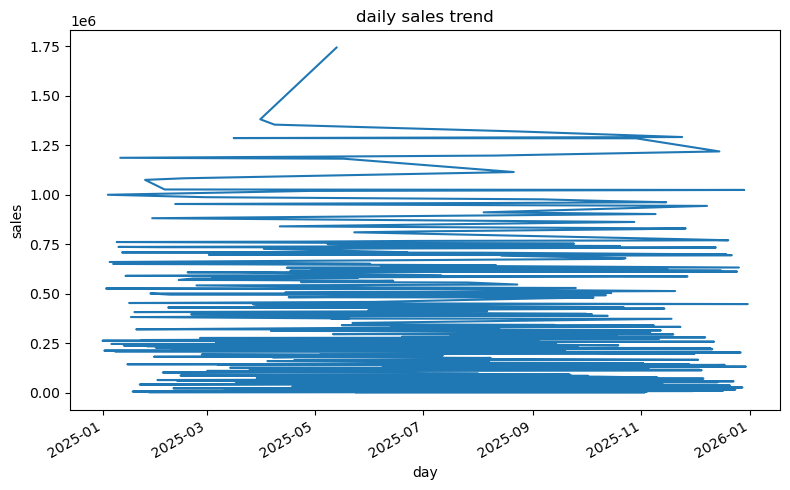

In [19]:
# creating line charts:

plt.figure(figsize= (8, 5))
daily_sales.plot(kind="line")
plt.title("daily sales trend")
plt.xlabel("day")
plt.ylabel("sales")

plt.tight_layout()

plt.show()

In [21]:
# PIE CHARTS CREATION:
# SALES DISTRIBUTION BY CATEGORY:
sales_distribution = df.groupby("category")["sales"].sum().sort_values(ascending= False)
print(sales_distribution)

category
Electronics    113477200.0
Accessories      7588780.0
Wearables        6260760.0
Name: sales, dtype: float64


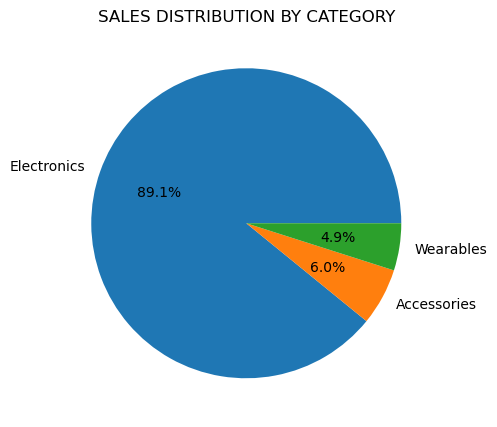

In [28]:
# ploting pie charts:

plt.figure(figsize= (5, 7))
sales_distribution.plot(kind= "pie", autopct = "%1.1f%%")
plt.title("SALES DISTRIBUTION BY CATEGORY")
plt.ylabel("")
plt.show()


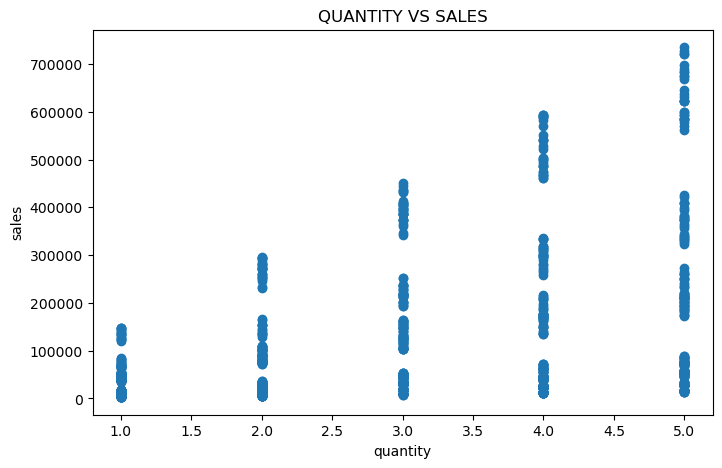

In [33]:
# cretaing scatter plot:
# quantity vs sales:
plt.figure(figsize= (8, 5))
plt.scatter(df["quantity"], df["sales"])
plt.title("QUANTITY VS SALES")
plt.xlabel("quantity")
plt.ylabel("sales")

plt.show()

In [34]:
# bar charts "order by payment method:

payment_count = df["payment_method"].value_counts()
print(payment_count)

payment_method
Cash             278
Online           249
Bank Transfer    245
Card             228
Name: count, dtype: int64


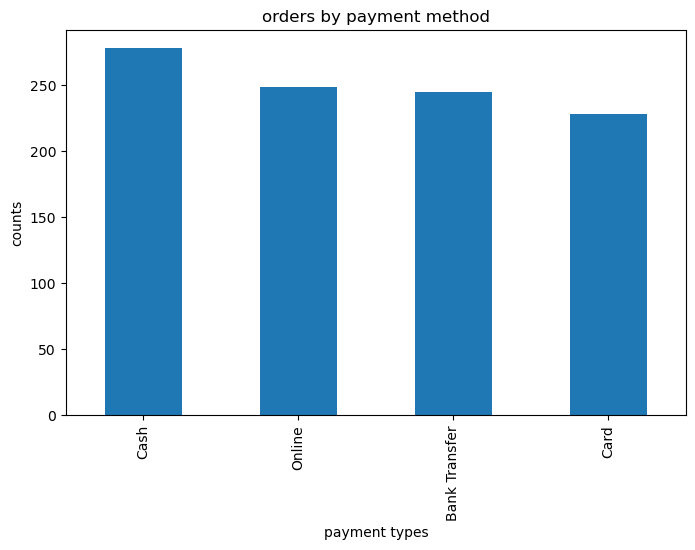

In [37]:
# crating bar charts:

plt.figure(figsize= (8, 5))
payment_count.plot(kind="bar")
plt.title("orders by payment method")
plt.xlabel("payment types")
plt.ylabel("counts")
plt.show()

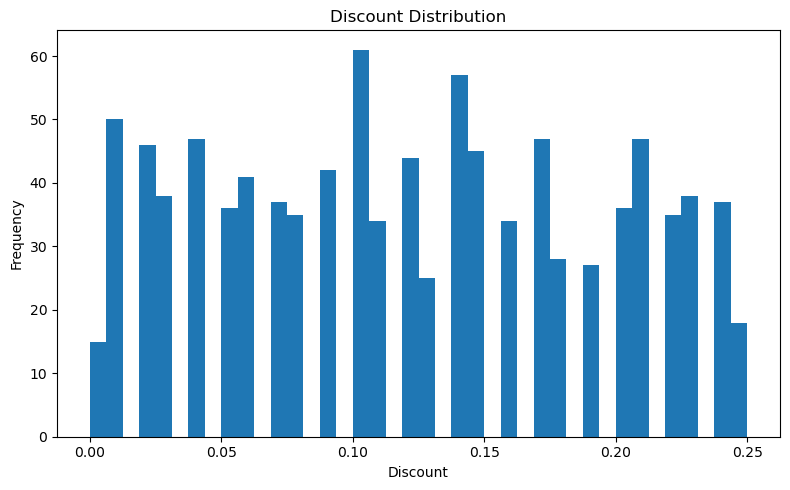

In [48]:
# discoun distribution:
# creating histogram

plt.figure(figsize=(8, 5))
plt.hist(df["discount"], bins=40)
plt.title("Discount Distribution")

plt.xlabel("Discount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [49]:
print("Total Orders:", len(df))

print(
    "Total Sales:",
    df["sales"].sum()
)

print(
    "Average Order Value:",
    df["sales"].mean()
)

print(
    "Best Selling Product:",
    df.groupby("product")["sales"]
      .sum()
      .idxmax()
)

print(
    "Best Performing City:",
    df.groupby("city")["sales"]
      .sum()
      .idxmax()
)

print(
    "Best Performing Category:",
    df.groupby("category")["sales"]
      .sum()
      .idxmax()
)

Total Orders: 1000
Total Sales: 127326740.0
Average Order Value: 127326.74
Best Selling Product: Laptop
Best Performing City: Multan
Best Performing Category: Electronics
